EDA Hipermercado

#### Starter (PDF) preguntas preguntas a responder:

Starter = qué está pasando
Analytics = por qué está pasando y qué hacer


+ ¿Qué categoría y subcategoría genera más ventas?
+ ¿Qué región es más rentable?
+ ¿Hay subcategorías con ventas altas pero ganancia negativa?
+ ¿Cómo evolucionan las ventas mes a mes?
+ ¿Qué segmento de cliente es más valioso?


#### Oferta del Servicio
Para negocios que nunca analizaron sus datos. Ordeno todo lo que tenés y te digo qué está pasando realmente en tu negocio.
Reunión inicial para entender tu negocio
Limpieza y ordenamiento de tus datos
Reporte PDF con 5–8 hallazgos clave


## Pendientes para completar el Starter

**`01_EDA.ipynb`**
- [X] Verificar duplicados
- [X] Gráfico 1: Ventas por categoría (barras horizontales)
- [X] Gráfico 2: Evolución mensual de ventas por año (línea)
- [X] Gráfico 3: Rentabilidad por región (barras)
- [X] Gráfico 4: Subcategorías con ganancia negativa (barras divergentes)
- [X] Gráfico 5: Ventas por segmento de cliente (barras)
- [ ] Exportar los 5 gráficos como `.png` en `outputs/graficos/`
- [ ] Exportar `superstore_limpio.csv` en `data/`
- [ ] Grafico X++: Ventas por subcategoria, 

**PDF del Starter**
- [ ] Script Python que arma el PDF con los 5 hallazgos + gráficos
- [ ] Redacción de los hallazgos en lenguaje de negocio


Celda 1 — Imports y carga ✅
Celda 2 — Limpieza y corrección ✅
Celda 3 — Estadística descriptiva  ← entramos acá
Celda 4 — Gráficos de análisis     ← gráfico 1 ya está
Celda 5 — Exportar CSV limpio      ← al final

In [1]:
# Simulación de análisis para cliente distribuidora
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Estilo general de gráficos ──

plt.rcParams['figure.facecolor'] = '#0e0e0e'
plt.rcParams['axes.facecolor']   = '#1a1a1a'
plt.rcParams['axes.edgecolor']   = '#333333'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['xtick.color']      = '#888888'
plt.rcParams['ytick.color']      = '#888888'
plt.rcParams['grid.color']       = '#2a2a2a'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'

Carga e Inspeccion de datos

In [3]:
#Carga e Inspeccion de datos
df = pd.read_csv('..\data\Sample - Superstore.csv', encoding='latin-1')
print("--- Inspección Inicial ---")
print("\n",df.info())
print(f"\nValores Nulos:\n{df.isnull().sum()}")
# Verificación de duplicados
print(f"Duplicados: {df.duplicated().sum()}")


--- Inspección Inicial ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-n

In [4]:
print("--- Vista General ---")
df.head()

--- Vista General ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Limpieza de datos 

In [5]:
# Renombrar columnas al español y sin espacios (más cómodo en PBI)
df = df.rename(columns={
    'Row ID'        : 'ID_Fila',
    'Order ID'      : 'ID_Orden',
    'Order Date'    : 'Fecha_Orden',
    'Ship Date'     : 'Fecha_Envio',
    'Ship Mode'     : 'Modo_Envio',
    'Customer ID'   : 'ID_Cliente',
    'Customer Name' : 'Nombre_Cliente',
    'Segment'       : 'Segmento',
    'Country'       : 'Pais',
    'City'          : 'Ciudad',
    'State'         : 'Estado',
    'Postal Code'   : 'Codigo_Postal',
    'Region'        : 'Region',
    'Product ID'    : 'ID_Producto',
    'Category'      : 'Categoria',
    'Sub-Category'  : 'Subcategoria',
    'Product Name'  : 'Nombre_Producto',
    'Sales'         : 'Ventas',
    'Quantity'      : 'Cantidad',
    'Discount'      : 'Descuento',
    'Profit'        : 'Ganancia',
})

# Verificación rápida
df.head()

,ID_Fila,ID_Orden,Fecha_Orden,Fecha_Envio,Modo_Envio,ID_Cliente,Nombre_Cliente,Segmento,Pais,Ciudad,...,Codigo_Postal,Region,ID_Producto,Categoria,Subcategoria,Nombre_Producto,Ventas,Cantidad,Descuento,Ganancia
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
#Conversion de fechas a datetime
df['Fecha_Orden'] = pd.to_datetime(df['Fecha_Orden'], format='%m/%d/%Y')
df['Fecha_Envio'] = pd.to_datetime(df['Fecha_Envio'], format='%m/%d/%Y')


#Creacion de columnas de tiempo "independientes"
df['Año']        = df['Fecha_Orden'].dt.year
df['Mes']        = df['Fecha_Orden'].dt.month
df['Mes_Nombre'] = df['Fecha_Orden'].dt.strftime('%B')
df['Trimestre']  = df['Fecha_Orden'].dt.quarter

In [7]:

# Agrupar Ventas por Categoria 
ventas_categoria = (df.groupby('Categoria')['Ventas']
                    .sum()
                    .sort_values(ascending=True))

In [8]:

# KPIs para el resumen ejecutivo
ventas_totales = df['Ventas'].sum()
ganancia_total = df['Ganancia'].sum()
margen_promedio = (ganancia_total / ventas_totales * 100)
total_ordenes = df['ID_Orden'].nunique()
mejor_año = df.groupby('Año')['Ventas'].sum().idxmax()
ventas_mejor_año = df.groupby('Año')['Ventas'].sum().max()

print(f"Ventas totales:   ${ventas_totales:,.0f}")
print(f"Ganancia total:   ${ganancia_total:,.0f}")
print(f"Margen promedio:  {margen_promedio:.1f}%")
print(f"Total órdenes:    {total_ordenes:,}")
print(f"Mejor año:        {mejor_año} (${ventas_mejor_año:,.0f})")



Ventas totales:   $2,297,201
Ganancia total:   $286,397
Margen promedio:  12.5%
Total órdenes:    5,009
Mejor año:        2017 ($733,215)


In [9]:
# Exploración de columnas categóricas
categoricas = ['Segmento', 'Region', 'Categoria', 'Subcategoria', 
               'Modo_Envio', 'Pais']

for col in categoricas:
    print(f"\n{col} — {df[col].nunique()} valores únicos:")
    print(df[col].value_counts())
    print("-" * 40)


Segmento — 3 valores únicos:
Segmento
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64
----------------------------------------

Region — 4 valores únicos:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
----------------------------------------

Categoria — 3 valores únicos:
Categoria
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
----------------------------------------

Subcategoria — 17 valores únicos:
Subcategoria
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64
----------------------------------------

Modo_Envio — 4 valores únicos:
M

In [10]:
ventas_categoria

Categoria
Office Supplies    719047.0320
Furniture          741999.7953
Technology         836154.0330
Name: Ventas, dtype: float64

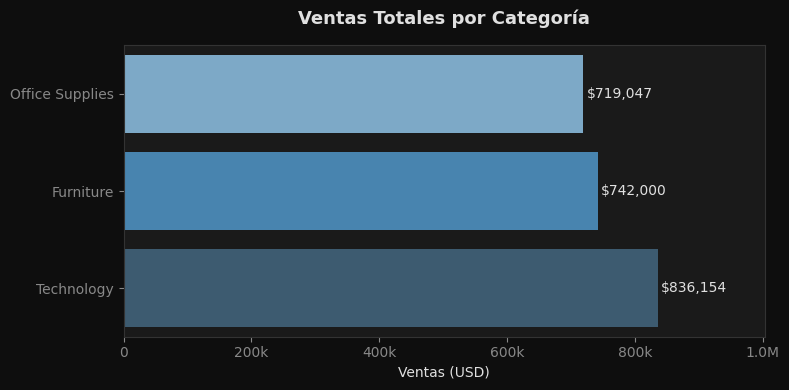

In [11]:
# Gráfico 1 - Ventas por Categoría
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x=ventas_categoria.values,
            y=ventas_categoria.index,
            palette='Blues_d',
            ax=ax)

ax.set_title('Ventas Totales por Categoría', pad=15)
ax.set_xlabel('Ventas (USD)')
ax.set_ylabel('')
plt.xlim(0, ventas_categoria.values.max() * 1.2)  # Espacio para etiquetas


# Etiquetas con el valor al lado de cada barra
# Recorre cada barra del gráfico y le escribe al lado el valor de ventas.
for i, v in enumerate(ventas_categoria.values):
    ax.text(v + 5000, i, f'${v:,.0f}', va='center', fontsize=10)

#Ese v + 5000 es  para que el texto quede a la derecha de la barra, no encima.

# Formato de eje X para mostrar en miles o millones
def formato_mixto(x, _):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'   # millones
    elif x >= 1_000:
        return f'{x/1000:.0f}k'        # miles
    else:
        return f'{x:.0f}'               # valores pequeños

ax.xaxis.set_major_formatter(mticker.FuncFormatter(formato_mixto))


plt.tight_layout()
plt.show()

Conclusion personal:

En este graficvo de ventas podemos ver que la categoria mas rentable por encima de las dema en Technology, con un monto total de ventas de >830k U$D, luego lo siguen Furniuture (719k U$D) y Office Supplies (742k U$D).
Estas ventas representas el historico ventas.

Observacion IA:

Ventas no es lo mismo que rentabilidad. Technology tiene más ventas, pero eso no significa que sea la más rentable. Puede vender mucho y ganar poco si tiene descuentos altos o costos altos. La categoría más rentable la ves con la columna Ganancia, no Ventas. 

Correción:

"Technology es la categoría con mayor volumen de ventas (>830k USD), seguida de Office Supplies (742k) y Furniture (719k). Sin embargo, volumen de ventas no implica mayor rentabilidad — eso lo analizamos a continuación."

In [12]:
#Grafico 2 - Evolución mensual de ventas por año

# Agrupamos ventas por año y mes
evolucion = df.groupby(['Año','Mes'])['Ventas'].sum().reset_index()

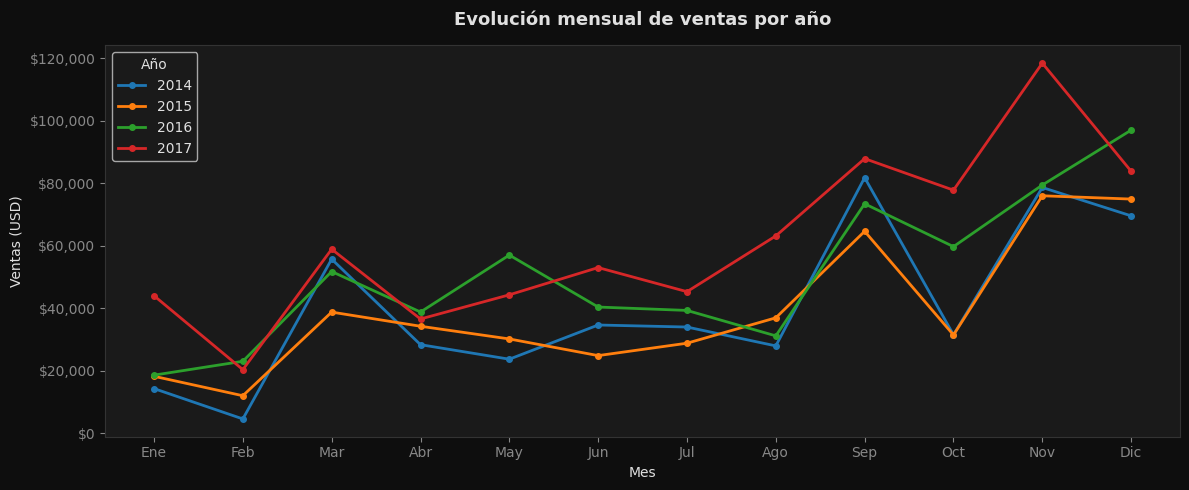

In [13]:
# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))

# Una línea por año
for año in evolucion['Año'].unique():
    data_año = evolucion[evolucion['Año'] == año]
    ax.plot(data_año['Mes'], data_año['Ventas'],
            marker='o', linewidth=2, markersize=4, label=str(año))

ax.set_title('Evolución mensual de ventas por año', pad=15)
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas (USD)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
ax.legend(title='Año')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


In [14]:
tabla_canva = evolucion.pivot_table(
    index='Mes',
    columns='Año',
    values='Ventas'
).reset_index()
tabla_canva['Mes'] = tabla_canva['Mes'].apply(lambda x: ['Ene','Feb','Mar','Abr','May','Jun',
                                                          'Jul','Ago','Sep','Oct','Nov','Dic'][x-1])
tabla_canva.to_csv("ventas_canva.csv", index=False, encoding="utf-8")


In [15]:
# Verificar rango de fechas
print(df['Fecha_Orden'].min())
print(df['Fecha_Orden'].max())
print(df.groupby('Año')['Fecha_Orden'].count())


2014-01-03 00:00:00
2017-12-30 00:00:00
Año
2014    1993
2015    2102
2016    2587
2017    3312
Name: Fecha_Orden, dtype: int64


Conclusion personal: 

Se puede ver como en el untimo año 2017 se mantiene una caida en las ventas en relacion al otros anos a fianles de Noviembre hasta diciembre, descocidiendo con los picos de ventas por navidad (si es afecta el negocio), ademas de una disminucion en el balance general del cierre de ese año, en años anteriores ese margen es posivo en relacion del principio del año, se ve que la cauida normal de ventas que es de Diciembre a Enero (Vacacione), se duio meses antes y el año 2017 empezo con mayores ventas Enero, entonces 2016 temino con mas ganacias y 2017 con menos 

Obsevacion de la IA:

"el dataset de 2017 puede estar incompleto" — esto no lo dijiste pero deberías verificarlo. Si el dataset cubre hasta cierto mes de 2017 y no el año completo, la comparación anual es inválida.

Correccion:

"Las ventas muestran crecimiento sostenido año a año. Febrero es el mes más débil de forma consistente en todos los años — ideal para planificar promociones o reducir stock. Noviembre es el pico máximo, probablemente por temporada de fin de año. El negocio tiene estacionalidad predecible, lo que permite planificar con anticipación."


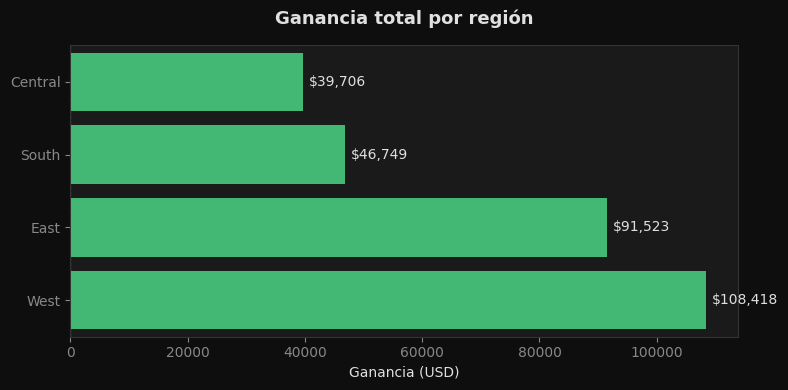

In [16]:
#Grafico 3 - Ganancia total por región
# Agrupamos ventas Y ganancia por región
rentabilidad_region = (df.groupby('Region')[['Ventas', 'Ganancia']]
                         .sum()
                         .sort_values('Ganancia', ascending=True))

fig, ax = plt.subplots(figsize=(8, 4))

# Barras de ganancia con color condicional: verde si gana, rojo si pierde
colores = ['#e74c3c' if g < 0 else '#2ecc71' for g in rentabilidad_region['Ganancia']]

sns.barplot(x=rentabilidad_region['Ganancia'],
            y=rentabilidad_region.index,
            palette=colores,
            ax=ax)

ax.set_title('Ganancia total por región', pad=15)
ax.set_xlabel('Ganancia (USD)')
ax.set_ylabel('')
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')

# Etiquetas
for i, v in enumerate(rentabilidad_region['Ganancia']):
    offset = 1000 if v >= 0 else -8000
    ax.text(v + offset, i, f'${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#de este mismo grafico hacelo havelo en vetical con x cortando en 0
#hacerlo tambien por estado o ciudad o usar un plot de mapa para mostrar rentabilidad por estado o ciudad?

In [32]:
tabla_canva = rentabilidad_region.reset_index()
tabla_canva.columns = ['Región', 'Ventas', 'Ganancia']
tabla_canva['Color'] = tabla_canva['Ganancia'].apply(lambda g: 'Positivo' if g >= 0 else 'Negativo')
tabla_canva = tabla_canva.sort_values('Ganancia', ascending=True)

tabla_canva.to_csv("ganancia_por_region_canva.csv", index=False, encoding="utf-8")


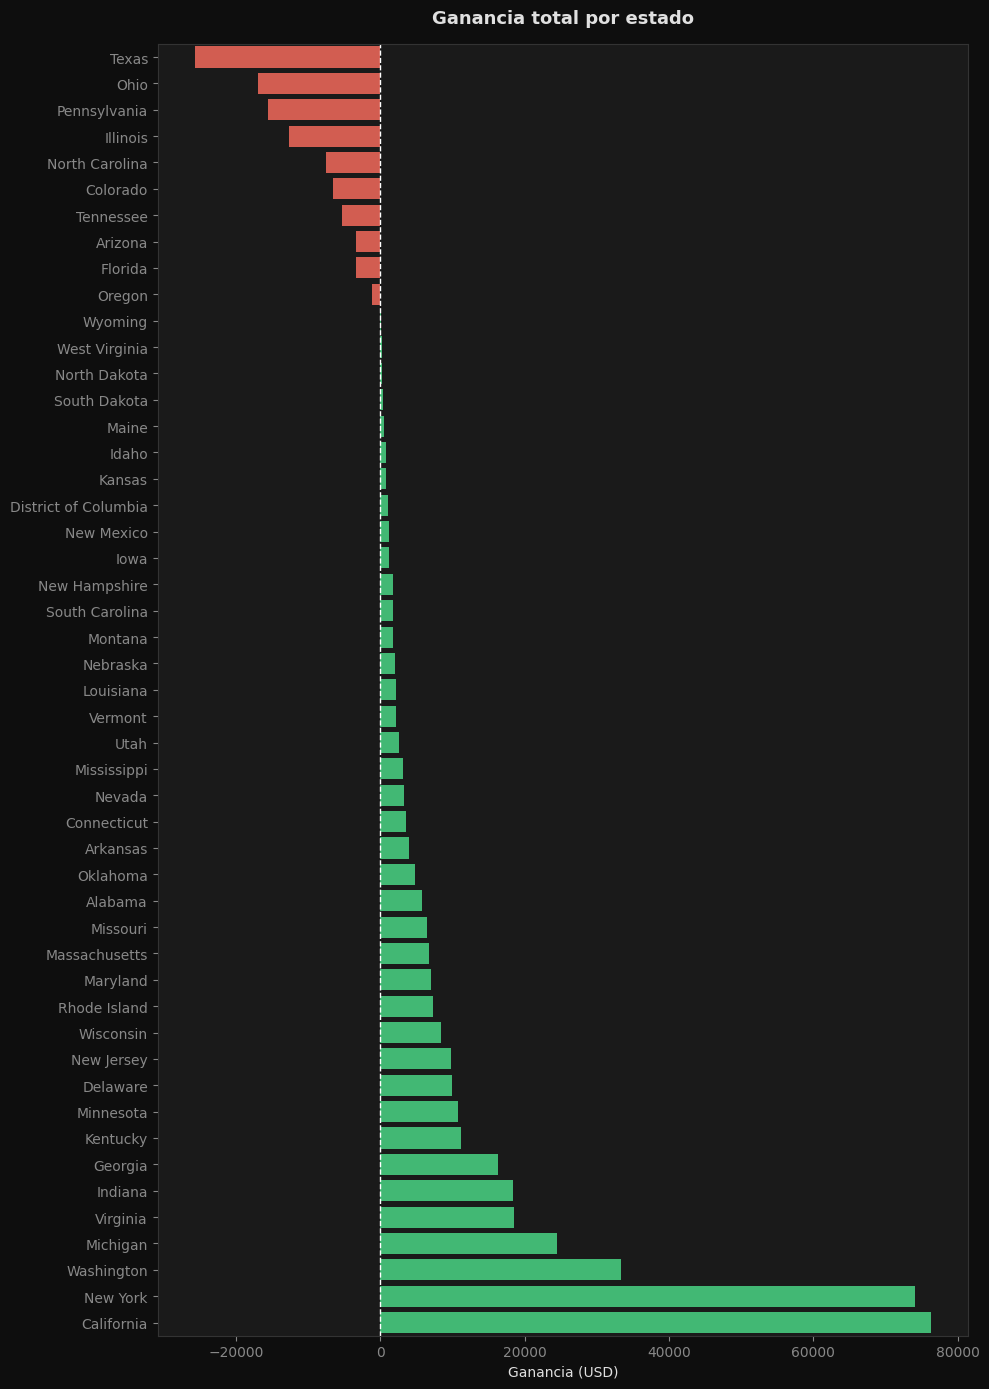

In [17]:
# Ganancia por estado
ganancia_estado = (df.groupby('Estado')['Ganancia']
                     .sum()
                     .sort_values(ascending=True))

# Separamos ganadores y perdedores
colores = ['#e74c3c' if g < 0 else '#2ecc71' for g in ganancia_estado.values]

fig, ax = plt.subplots(figsize=(10, 14))

sns.barplot(x=ganancia_estado.values,
            y=ganancia_estado.index,
            palette=colores,
            ax=ax)

ax.set_title('Ganancia total por estado', pad=15)
ax.set_xlabel('Ganancia (USD)')
ax.set_ylabel('')

# Línea en 0 — referencia visual clave
ax.axvline(0, color='white', linewidth=1, linestyle='--')

plt.tight_layout()
plt.show()

In [27]:
tabla_canva = ganancia_estado.reset_index()
tabla_canva.columns = ['Estado', 'Ganancia']
tabla_canva['Color'] = tabla_canva['Ganancia'].apply(lambda g: 'Positivo' if g >= 0 else 'Negativo')
tabla_canva = tabla_canva.sort_values('Ganancia', ascending=True)

tabla_canva.to_csv("ganancia_por_estado_canva.csv", index=False, encoding="utf-8")


Conclusión para el PDF con estos dos gráficos

> *"A nivel regional todas las zonas son rentables, lideradas por West (108k) y East (91k). Sin embargo al analizar por estado aparecen 10 estados con ganancia negativa, siendo Texas el más crítico con más de $25k de pérdida acumulada. California y New York compensan ampliamente esas pérdidas a nivel regional, ocultando el problema. Estos estados merecen análisis prioritario."*


yo:
ahora si habias lugares donde hbaia perdida y valdria la pena ahcer esto mismo en los lugares donde hay perdida para saber si es asi en todo el estado o solo en algunas ciudades ? o eso si el cliente lo pide mejor?

cluade:
Exacto, tu intuición es correcta. Pero eso ya es **Analytics**, no Starter.

El Starter muestra el problema. El Analytics encuentra la causa. La lógica comercial es:

```
Starter  →  "Texas está perdiendo $20k"
Analytics →  "En Texas, las pérdidas se concentran 
              en 3 ciudades y son causadas por 
              descuentos mayores al 40%"
```

Cuando le entregás el Starter al cliente y ve Texas en rojo, su pregunta natural va a ser *"¿por qué?"*. Ahí le ofrecés el Analytics. Eso es exactamente cómo se vende el siguiente paquete sin tener que venderlo — el dato lo vende solo.

Por ahora anotá esto en tu notebook:

> *"Drill-down por ciudad en estados con pérdida (Texas, Ohio, Pennsylvania, Illinois) — reservado para paquete Analytics."*


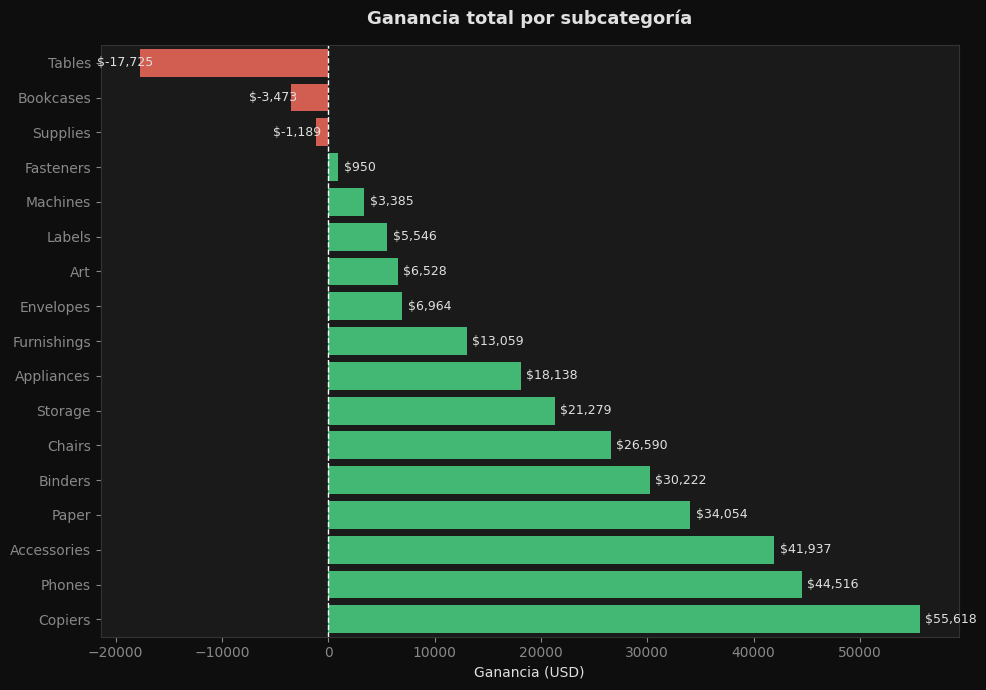

In [18]:
# Grafico 4 - Ganancia total por subcategoría
# Ganancia por subcategoría
ganancia_subcat = (df.groupby('Subcategoria')['Ganancia']
                     .sum()
                     .sort_values(ascending=True))

colores = ['#e74c3c' if g < 0 else '#2ecc71' for g in ganancia_subcat.values]

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(x=ganancia_subcat.values,
            y=ganancia_subcat.index,
            palette=colores,
            ax=ax)

ax.set_title('Ganancia total por subcategoría', pad=15)
ax.set_xlabel('Ganancia (USD)')
ax.set_ylabel('')
ax.axvline(0, color='white', linewidth=1, linestyle='--')

for i, v in enumerate(ganancia_subcat.values):
    offset = 500 if v >= 0 else -4000
    ax.text(v + offset, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
tabla_canva = ganancia_subcat.reset_index()
tabla_canva.columns = ['Subcategoría', 'Ganancia']
tabla_canva['Color'] = tabla_canva['Ganancia'].apply(lambda g: 'Positivo' if g >= 0 else 'Negativo')
tabla_canva = tabla_canva.sort_values('Ganancia', ascending=True)
tabla_canva.to_csv("ganancia_por_subcategoria_canva.csv", index=False, encoding="utf-8")

In [19]:
# Ver ventas VS ganancia de las 3 subcategorías en pérdida
perdedoras = ['Tables', 'Bookcases', 'Supplies']

df[df['Subcategoria'].isin(perdedoras)].groupby('Subcategoria')[['Ventas', 'Ganancia', 'Descuento']].agg({
    'Ventas': 'sum',
    'Ganancia': 'sum',
    'Descuento': 'mean'
}).round(2)

,Ventas,Ganancia,Descuento
Subcategoria,,,
Bookcases,114880.00,-3472.56,0.21
Supplies,46673.54,-1189.10,0.08
Tables,206965.53,-17725.48,0.26


Esa es la conclusión para el PDF:

"Tres subcategorías operan con pérdida acumulada: Tables (-$17.7k), Bookcases (-$3.4k) y Supplies (-$1.1k). El factor común es el descuento promedio aplicado — Tables tiene un 26% de descuento medio, casi el triple que Supplies. El problema no es el producto sino la política de descuentos. Reducir el descuento en Tables al 10-15% probablemente eliminaría la pérdida sin afectar el volumen de ventas."

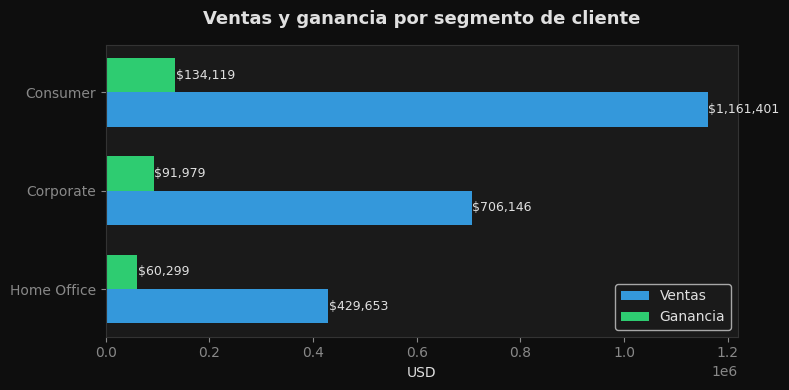

In [20]:
# Ventas y ganancia por segmento
segmento = (df.groupby('Segmento')[['Ventas', 'Ganancia']]
              .sum()
              .sort_values('Ventas', ascending=True))

fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(segmento))
width = 0.35

bars1 = ax.barh([i - width/2 for i in x], segmento['Ventas'],
                height=width, label='Ventas', color='#3498db')
bars2 = ax.barh([i + width/2 for i in x], segmento['Ganancia'],
                height=width, label='Ganancia', color='#2ecc71')

ax.set_yticks(list(x))
ax.set_yticklabels(segmento.index)
ax.set_title('Ventas y ganancia por segmento de cliente', pad=15)
ax.set_xlabel('USD')
ax.legend()

# Etiquetas
for bar in bars1:
    w = bar.get_width()
    ax.text(w + 1000, bar.get_y() + bar.get_height()/2,
            f'${w:,.0f}', va='center', fontsize=9)

for bar in bars2:
    w = bar.get_width()
    ax.text(w + 1000, bar.get_y() + bar.get_height()/2,
            f'${w:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
#margen real de cada uno
segmento_margen = df.groupby('Segmento')[['Ventas','Ganancia']].sum()
segmento_margen['Margen_%'] = (segmento_margen['Ganancia'] / segmento_margen['Ventas'] * 100).round(2)
segmento_margen

,Ventas,Ganancia,Margen_%
Segmento,,,
Consumer,1.161401e+06,134119.2092,11.55
Corporate,7.061464e+05,91979.1340,13.03
Home Office,4.296531e+05,60298.6785,14.03


La conclusión para el PDF:

"Consumer es el segmento dominante en volumen ($1.16M) pero el menos eficiente — convierte solo el 11.5% en ganancia. Home Office, siendo el más pequeño, tiene el mejor margen (~14%). Si el objetivo es rentabilidad, Corporate y Home Office merecen atención prioritaria en estrategia comercial."


Top 10 productos por ventas:


Nombre_Producto
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Ventas, dtype: float64

Top 10 clientes por ganancia generada:


Nombre_Cliente
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Ganancia, dtype: float64

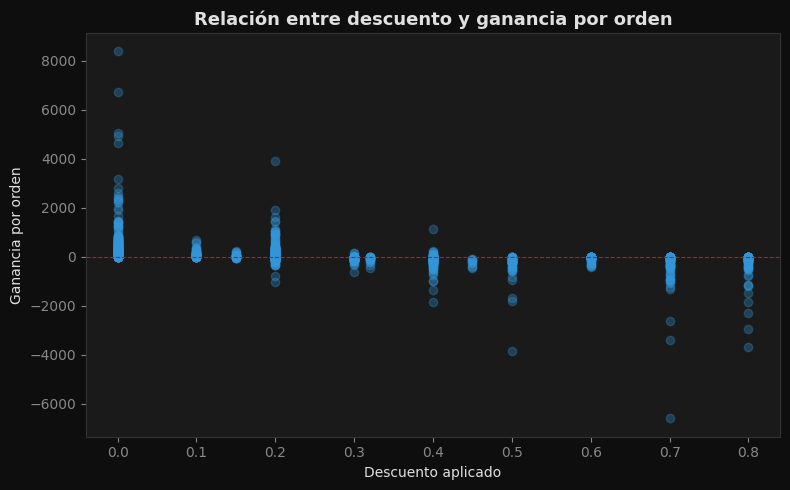

In [22]:
# Top 10 productos más vendidos por ventas
top_productos = (df.groupby('Nombre_Producto')['Ventas']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))
print("Top 10 productos por ventas:")
display(top_productos)
# Top 10 clientes por ganancia generada
top_clientes = (df.groupby('Nombre_Cliente')['Ganancia']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))
print("Top 10 clientes por ganancia generada:")
display(top_clientes)
# Relación descuento vs ganancia — scatter plot
# Muestra visualmente si a mayor descuento menor ganancia
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df['Descuento'], df['Ganancia'], alpha=0.3, color='#3498db')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.set_xlabel('Descuento aplicado')
ax.set_ylabel('Ganancia por orden')
ax.set_title('Relación entre descuento y ganancia por orden')
plt.tight_layout()
plt.show()

In [36]:
tabla_canva_sample = df[['Descuento', 'Ganancia']].sample(n=1000, random_state=42)
tabla_canva_sample.to_csv("descuento_vs_ganancia_canva.csv", index=False, encoding="utf-8")


In [23]:
# Estadisticas 

# Recrear columna de margen
df['Margen_%'] = (df['Ganancia'] / df['Ventas'] * 100).round(2)

# Ahora sí el describe
df[['Ventas', 'Ganancia', 'Cantidad', 'Descuento', 'Margen_%']].describe().round(2)

,Ventas,Ganancia,Cantidad,Descuento,Margen_%
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,3.79,0.16,12.03
std,623.25,234.26,2.23,0.21,46.68
min,0.44,-6599.98,1.00,0.00,-275.00
25%,17.28,1.73,2.00,0.00,7.50
50%,54.49,8.67,3.00,0.20,27.00
75%,209.94,29.36,5.00,0.20,36.25
max,22638.48,8399.98,14.00,0.80,50.00


Ventas

Orden promedio: $229. Pero la std es $623 — casi el triple. Eso significa que hay órdenes muy grandes que inflan el promedio. El 50% de las órdenes reales están por debajo de $54. Es un negocio de volumen alto con tickets mayormente chicos.

Ganancia

Promedio por orden: $28. Parece poco pero es consistente con el margen del 12%.
El mínimo es -$6,599 en una sola orden. Esa orden destruyó más ganancia que lo que generan 230 órdenes promedio. Vale la pena identificarla.
La std de $234 vs media de $28 confirma altísima variabilidad — hay órdenes muy rentables y órdenes muy destructivas.

Descuento

Promedio: 16%. Parece razonable.
Pero el 50% de las órdenes tienen descuento de 20% o más. Eso es alto.
Máximo: 80%. Alguien está regalando producto.

Margen_%

Promedio: 12%. Pero la std es 46% y el mínimo es -275%. Eso confirma que hay órdenes individuales que son desastres totales.

In [24]:
# La orden más destructiva
display(df.nsmallest(3, 'Ganancia')[['ID_Orden','Nombre_Producto',
                                   'Ventas','Ganancia','Descuento']])

# Órdenes con descuento del 80%
display(df[df['Descuento'] == 0.8][['ID_Orden','Nombre_Producto',
                                   'Ventas','Ganancia']].head(5))

,ID_Orden,Nombre_Producto,Ventas,Ganancia,Descuento
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,-6599.9780,0.7
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,0.5
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,2177.584,-3701.8928,0.8


,ID_Orden,Nombre_Producto,Ventas,Ganancia
14,US-2015-118983,Holmes Replacement Filter for HEPA Air Cleaner...,68.810,-123.8580
15,US-2015-118983,Storex DuraTech Recycled Plastic Frosted Binders,2.544,-3.8160
75,US-2017-118038,Economy Binders,1.248,-1.9344
101,CA-2016-158568,Avery Hidden Tab Dividers for Binding Systems,1.788,-3.0396
169,CA-2014-139892,Kensington 7 Outlet MasterPiece Power Center,177.980,-453.8490



Segmento — 3 valores únicos:
Segmento
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64
----------------------------------------

Region — 4 valores únicos:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
----------------------------------------

Categoria — 3 valores únicos:
Categoria
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
----------------------------------------

Subcategoria — 17 valores únicos:
Subcategoria
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64
----------------------------------------

Modo_Envio — 4 valores únicos:
M

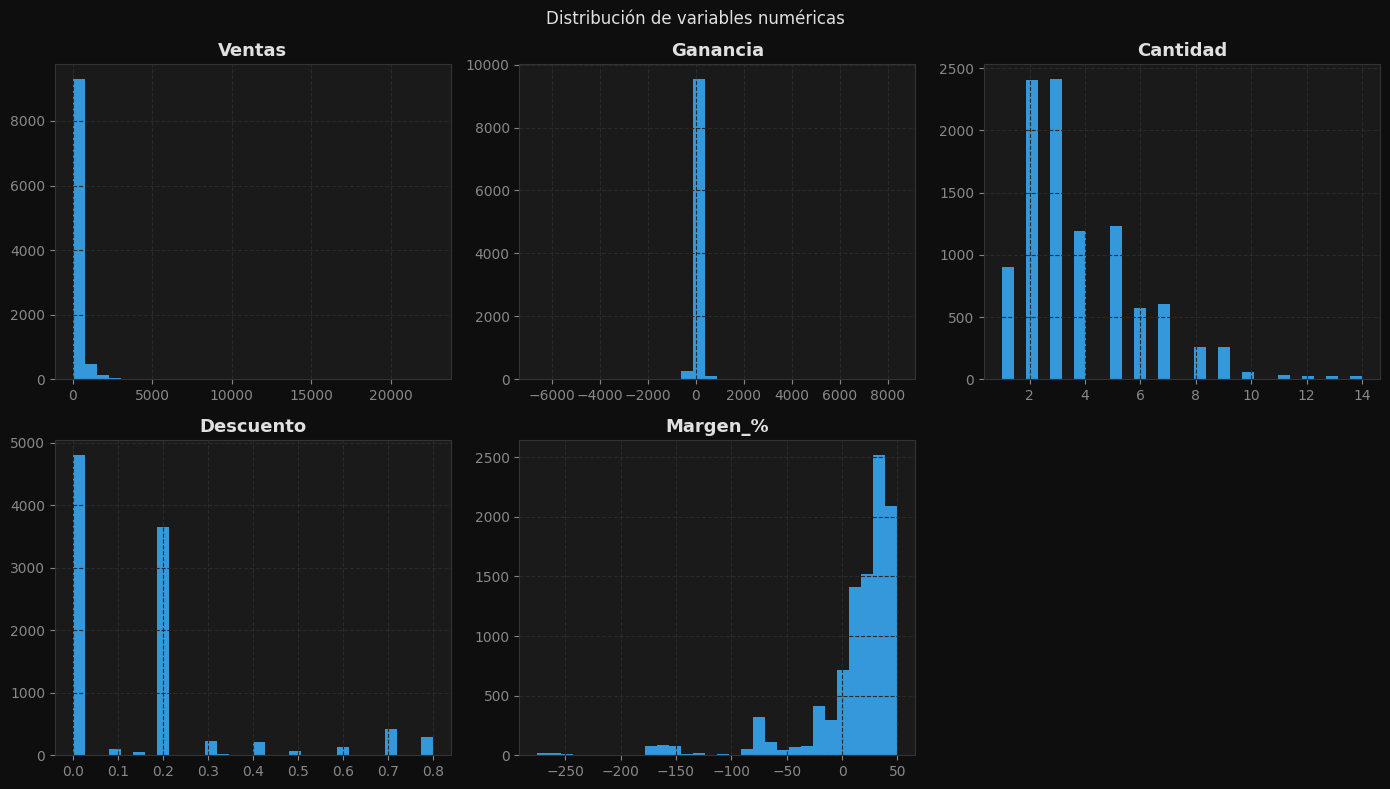


Top 3 órdenes con mayor pérdida:
            ID_Orden                            Nombre_Producto    Ventas  \
7772  CA-2016-108196  Cubify CubeX 3D Printer Double Head Print  4499.985   
683   US-2017-168116  Cubify CubeX 3D Printer Triple Head Print  7999.980   
9774  CA-2014-169019  GBC DocuBind P400 Electric Binding System  2177.584   

       Ganancia  Descuento  
7772 -6599.9780        0.7  
683  -3839.9904        0.5  
9774 -3701.8928        0.8  

Órdenes con descuento máximo (80%):
           ID_Orden                                    Nombre_Producto  \
14   US-2015-118983  Holmes Replacement Filter for HEPA Air Cleaner...   
15   US-2015-118983   Storex DuraTech Recycled Plastic Frosted Binders   
75   US-2017-118038                                    Economy Binders   
101  CA-2016-158568      Avery Hidden Tab Dividers for Binding Systems   
169  CA-2014-139892       Kensington 7 Outlet MasterPiece Power Center   

      Ventas  Ganancia  
14    68.810 -123.8580  
15     2.

In [25]:
# ── Univariado categóricas ──────────────────────────
categoricas = ['Segmento', 'Region', 'Categoria', 
               'Subcategoria', 'Modo_Envio']

for col in categoricas:
    print(f"\n{col} — {df[col].nunique()} valores únicos:")
    print(df[col].value_counts())
    print("-" * 40)

# ── Univariado numéricas — histogramas ──────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols = ['Ventas', 'Ganancia', 'Cantidad', 'Descuento', 'Margen_%']

for i, col in enumerate(cols):
    ax = axes[i//3][i%3]
    df[col].hist(bins=30, ax=ax, color='#3498db', edgecolor='none')
    ax.set_title(col)

axes[1][2].set_visible(False)
plt.suptitle('Distribución de variables numéricas')
plt.tight_layout()
plt.show()

# ── Outliers — órdenes extremas ─────────────────────
print("\nTop 3 órdenes con mayor pérdida:")
print(df.nsmallest(3, 'Ganancia')[['ID_Orden', 'Nombre_Producto',
                                    'Ventas', 'Ganancia', 'Descuento']])

print("\nÓrdenes con descuento máximo (80%):")
print(df[df['Descuento'] == 0.8][['ID_Orden', 'Nombre_Producto',
                                   'Ventas', 'Ganancia']].head(5))

# ── Envíos ──────────────────────────────────────────
envio = df.groupby('Modo_Envio')[['Ventas', 'Ganancia']].sum()
envio['Margen_%'] = (envio['Ganancia'] / envio['Ventas'] * 100).round(2)
print("\nRendimiento por modo de envío:")
print(envio.sort_values('Margen_%', ascending=False))

#### El orden correcto del EDA

1. Carga y estructura
   └── shape, dtypes, nulos, duplicados

2. Exploración univariada
   └── cada variable sola
   └── categóricas: value_counts()
   └── numéricas: describe() + histogramas
   └── acá identificás outliers

3. Exploración bivariada
   └── relación entre variables
   └── acá están los hallazgos de negocio
   └── gráficos de barras, scatter, líneas

4. Conclusiones y exportación
   └── hallazgos para el PDF
   └── CSV limpio para PBI

Hallazgos confirmados para el PDF

Ahora sí tenemos todo. Los hallazgos del Starter son:
1. Crecimiento sostenido: órdenes crecen de 1993 a 3312 año a año
2. Estacionalidad clara: pico en Noviembre, caída en Febrero
3. 10 estados con pérdida oculta: Texas lidera con -$25k
4. Descuentos destruyen rentabilidad: Tables pierde $17k con 26% descuento promedio
5. Copiers es el producto estrella: 68 órdenes, $55k de ganancia
6. Una sola orden destruyó $6,599: impresora 3D con 70% de descuento
7. Política de descuentos es rígida: 0% o 20%, no hay término medio

In [26]:
# Exportar CSV limpio para Power BI
df.to_csv('..\data\superstore_limpio.csv', index=False, encoding='utf-8-sig')

print(f"Exportado: {df.shape[0]} filas, {df.shape[1]} columnas")

Exportado: 9994 filas, 26 columnas
